# Notebook example

In order to use this notebook, you need to install the HOD code at _https://github.com/jcallesh/HOD_. Normally, you would just use the command `pip install git+https://github.com/jcallesh/HOD.git`. However, this doesn't work for us because as it is written in that Github repository, that package relies on the deprecated _sklearn_, and we need to instead use _scikit-learn_.

In order to do this, I had to clone the aforementioned repository to create a local version of the repository. I then modified _setup.py_ in this local repository to use _scikit-learn_ instead of _sklearn_. However, before we can install the _pyhod_ package from this local repository, we have to set up a virtual environment to install the package into. To do this, we go to the NERSC terminal and put it into in a pre-set Python environment (with stuff like pip and conda pre-installed) - `module load python`

We then use _conda_ to create a new virtual environment that we can configure to our exact needs for the HOD code (by downloading the HOD package here then running the notebook out of this environment) - `conda create -n env_name python=3.11`. Note that we use Python version 3.11 because that was the latest version as of 2023 when the _pyhod_ code was first created. We enter the virtual environment with `conda activate env\_name` and use conda to install pip to that environment with `conda install pip`. 

We now navigate into the directory with the cloned HOD repository and install all the contents of the directory as a package to the virtual environment with `pip install .`. The final step is to make our new virtual environment a viable kernel from which we can run a jupyter notebook. We do this by first installing _ipykernel_ with `pip install ipykernel` and then we use the command `python -m ipykernel install --user --name=myenv`

There is a good chance you will also have to install _h5py_, _hdf5plugin_, _Pylians_ into your virtual environment on the command line with `pip install h5py`, `pip install hdf5plugin`, and `pip install Pylians`. I had trouble importing Pylians, so I might need to create a virtual environment with an older version of Python. However, it also might just be best for me to throw in the towel and just use a different HOD code. I sepnt a lot of time today reminding myself of virtual environment stuff and learning a lot more, but it might not even be worth trying to figure this out. I will find something else maybe.

In [1]:
# Load basic libraries from pyhod
import numpy as np
import pyhod.hodfunc as hf
import pyhod.utils as utils
import psutil

In [2]:
print(psutil.cpu_count())

256


## Load all input parameters

In [3]:
# To facilitate the usage of the functions on pyHOD we set the relevant parameters in the config.py module as a dictionary.
# Make sure that "config.py" is in your working directory
import config

In [4]:
# I print out the number of logical cores here because in the snapshot code for assigning satellite 
# galaxy velocities based on dark matter particles, we specify the number of CPU threads available.
# I set that variable in hodfunc.py as half the number of logical cores printed here.
params = config.input_params_nb()

## update params if not done in config.py

In [5]:
params['ifile'] = '/pscratch/sd/a/ajtorres/Quijote_Halos_Fiducial/0'
params['cat'] = 'Quijote_Halo'
params['outfile'] = '%s_HOD0_%s_1Gpc_z0.5_run0.npz'%(params['cat'],params['method'] )
params['method'] = 'SNAP'
params['ifile_snapshot'] = '/pscratch/sd/a/ajtorres/DM_Particle_Snapshots_Fiducial/0/snapdir_003/snap_003'
params['iRSD'] = 3

In [6]:
# check all the input parameters 
for key,value in params.items():
    print(key, ' : ', value)

box  :  1000
grid  :  256
z  :  0.5
Deltac  :  200
M_star  :  16709920000000.0
cat  :  Quijote_Halo
om  :  0.3175
ol  :  0.6825
h  :  0.6711
method  :  SNAP
model  :  Zheng
logMmin  :  13.0
alpha  :  0.75
logM1  :  14.25
sigmalogM  :  0.2
logM0  :  13.1
ifile  :  /pscratch/sd/a/ajtorres/Quijote_Halos_Fiducial/0
ifile_snapshot  :  /pscratch/sd/a/ajtorres/DM_Particle_Snapshots_Fiducial/0/snapdir_003/snap_003
outfile  :  Quijote_Halo_HOD0_NFW_1Gpc_z0.5_run0.npz
iRSD  :  0
zerr  :  0
seed  :  5761


//
Notice the random number generator is fixed in the parameter file.

use

> params['seed'] = newvalue

to change the random realization used in  'hf.cent_sat' and 'hf.sample_catalog'.

#  Read catalog

In [7]:
#pyHOD contains a library to help read different halo catalogs such as Quijote Halos or EoS Halo catalogs.
import pyhod.read as read

In [8]:
data = read.readcats(params = params)



Loading halos from
    --->FILE:/pscratch/sd/a/ajtorres/Quijote_Halos_Fiducial/0


In [9]:
print('Loaded %d halos, in the mass rage (%.2e,%.2e).\n' %(len(data[:,0]),data[:,0].min(),data[:,0].max()))

Loaded 309740 halos, in the mass rage (1.31e+13,2.09e+15).



#  Running HOD

In the basic implementation we follow the steps:
1. Compute the mean number of Galaxies $<N_{cen}>$ using the 5 HOD parameters (logMmin', 'sigmalogM','logM0','alpha','logM1')
1. Draw the galaxy samples

In [10]:
# COMPUTE MEAN NUMBER OF GALAXIES
HOD_param = params['logMmin'], params['sigmalogM'], params['logM0'], params['alpha'], params['logM1']
centrals, satellites = hf.cent_sat(data,*HOD_param, params = params)


Computing mean number central and satellites...

Drawing central and satellites...


In [ ]:
galaxy_pos, galaxy_vel, galaxy_type, halo_group = hf.sample_catalog(data, centrals, satellites, alpha = 1.0, params = params)

Doing SNAP

Assigning position and velocities for satellites galaxies...

loading snapshot:  /pscratch/sd/a/ajtorres/DM_Particle_Snapshots_Fiducial/0/snapdir_003/snap_003
drawing galaxies from snapshot 48007


In [ ]:
if params['iRSD'] > 0: 
    # The default is for params to be none, which means that we have to manually specify the configuration parameters
    # that we set above
    galaxy_pos = utils.displaceRSD(galaxy_pos, galaxy_vel, params)

In [13]:
output = params['outfile']
print('\nNow Saving at:\n    --->OUTPUT FILE:%s\n'%output)
np.savez_compressed(output, pos=galaxy_pos, vel =galaxy_vel, gtype = galaxy_type)


Now Saving at:
    --->OUTPUT FILE:Quijote_Halo_HOD0_NFW_1Gpc_z0.5_run0.npz



# Visual Inspection

In [14]:
import matplotlib.pyplot as plt

In [15]:
mycat = np.load(output)
vec = np.array([mycat['pos'][:,0],mycat['pos'][:,1],mycat['pos'][:,2],mycat['gtype']]).T    
npart = len(vec[:,0])
print('Found %d galaxies.' %npart)
print('Number density: %.2e (h/Mpc)^3'%(npart/params['box']**3))

Found 356317 galaxies.
Number density: 3.56e-04 (h/Mpc)^3


In [16]:
mask= (vec[:,2]>250)&(vec[:,2]<300)
pos_slice = vec[mask,:]

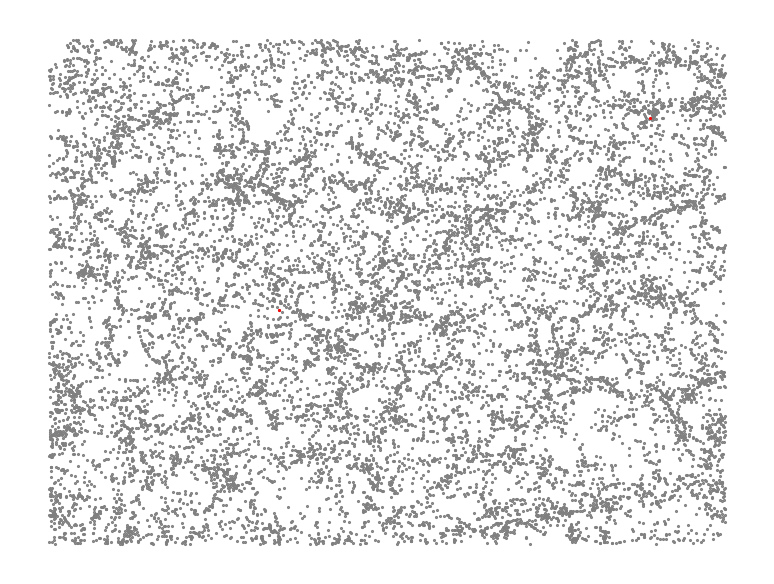

In [17]:
fig ,ax1 = plt.subplots(dpi=150)

# In the next two lines of uncommented code, we are effectively splitting the array 'pos_slice'
# into central and satellite galaxies. 'pos_slice[:,0:2]' extracts the xyz position coordinates
# for evert galaxy. [pos_slice[:-1].astype(bool)] then basically determines whether that galaxy
# is a central galaxy (True) or is a satellite galaxy (not False)
central = pos_slice[:,0:2][pos_slice[:,-1].astype(bool)]
satellites  = pos_slice[:,0:2][~pos_slice[:,-1].astype(bool)]

ax1.scatter(central[:,0],central[:,1],color='grey',s=0.25)
ax1.scatter(satellites[:,0],satellites[:,1],color='red',s=0.25)

plt.axis('off')
plt.show()